First 5 Records
   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40

Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB
None

Missing Value

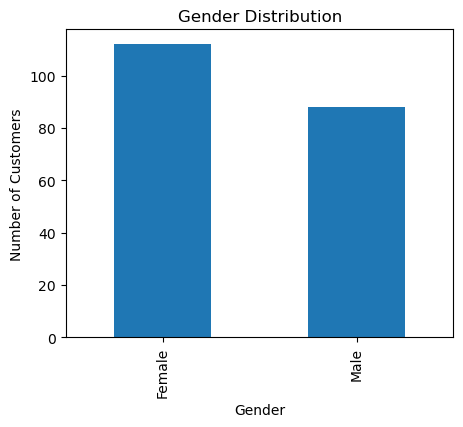

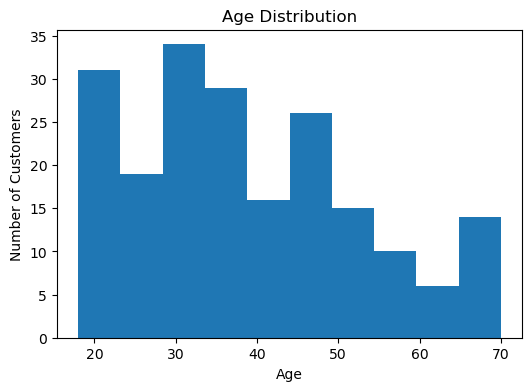

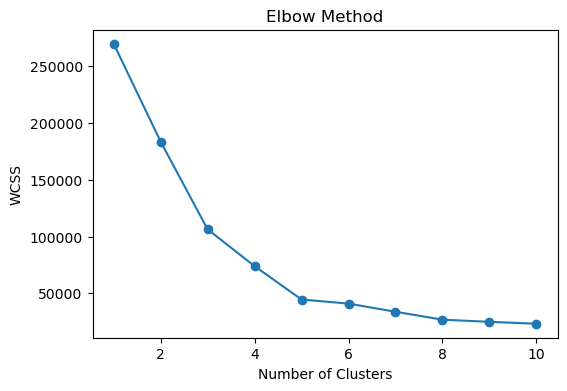

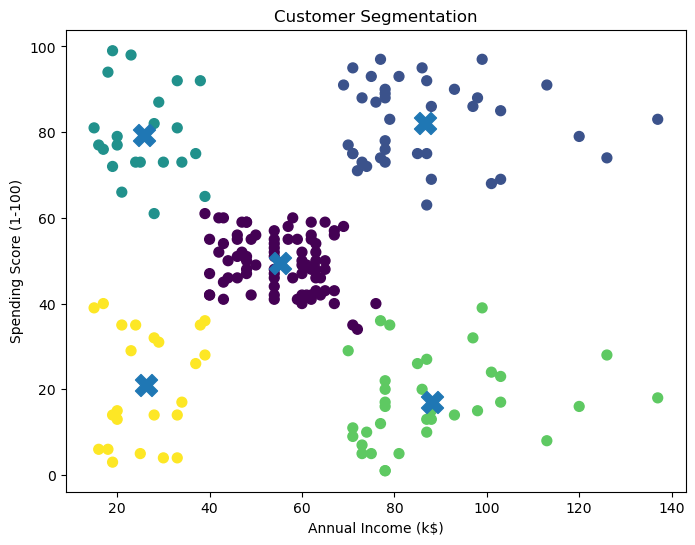


Average Values for Each Cluster
               Age  Annual Income (k$)  Spending Score (1-100)
Cluster                                                       
0        42.716049           55.296296               49.518519
1        32.692308           86.538462               82.128205
2        25.272727           25.727273               79.363636
3        41.114286           88.200000               17.114286
4        45.217391           26.304348               20.913043

Customers in Each Cluster
Cluster
0    81
1    39
2    22
3    35
4    23
Name: count, dtype: int64

Project Completed Successfully!


In [2]:
# ===============================
# CUSTOMER SEGMENTATION PROJECT
# ===============================

# Step 1: Import Libraries
import os
os.environ["OMP_NUM_THREADS"] = "1"   # Removes KMeans warning

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# Step 2: Load Dataset
df = pd.read_csv(r"C:\Users\fizak\Downloads\Mall_Customers.csv")

# Step 3: Display Dataset
print("First 5 Records")
print(df.head())

print("\nDataset Information")
print(df.info())

print("\nMissing Values")
print(df.isnull().sum())

# ===============================
# Step 4: Gender Distribution
# ===============================

plt.figure(figsize=(5,4))
df["Gender"].value_counts().plot(kind="bar")
plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Number of Customers")
plt.show()

# ===============================
# Step 5: Age Distribution
# ===============================

plt.figure(figsize=(6,4))
plt.hist(df["Age"], bins=10)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Customers")
plt.show()

# ===============================
# Step 6: Select Features
# ===============================

X = df[["Annual Income (k$)", "Spending Score (1-100)"]]

# ===============================
# Step 7: Elbow Method
# ===============================

wcss = []

for i in range(1,11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(6,4))
plt.plot(range(1,11), wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()

# ===============================
# Step 8: K-Means Clustering
# ===============================

kmeans = KMeans(n_clusters=5, random_state=42)

df["Cluster"] = kmeans.fit_predict(X)

# ===============================
# Step 9: Visualize Clusters
# ===============================

plt.figure(figsize=(8,6))

plt.scatter(
    df["Annual Income (k$)"],
    df["Spending Score (1-100)"],
    c=df["Cluster"],
    s=50
)

# Cluster Centers
centers = kmeans.cluster_centers_

plt.scatter(
    centers[:,0],
    centers[:,1],
    s=250,
    marker='X'
)

plt.title("Customer Segmentation")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.show()

# ===============================
# Step 10: Cluster Summary
# ===============================

summary = df.groupby("Cluster")[[
    "Age",
    "Annual Income (k$)",
    "Spending Score (1-100)"
]].mean()

print("\nAverage Values for Each Cluster")
print(summary)

# Number of customers in each cluster
print("\nCustomers in Each Cluster")
print(df["Cluster"].value_counts().sort_index())

# ===============================
# Step 11: Save Output
# ===============================

df.to_csv("Customer_Segmentation_Output.csv", index=False)

print("\nProject Completed Successfully!")